# SSSP demo, challenging scenarios

In [1]:
import Random: seed!
using MRMP

[ Info: Precompiling MRMP [c7aa4c1c-513e-40f4-a62b-c98230a9110a]


## point2d

  0.099396 seconds (71.67 k allocations: 3.475 MiB, 99.85% compilation time)


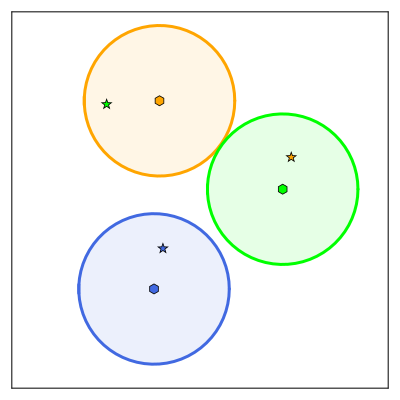

In [2]:
seed!(6)
@time ins = MRMP.gen_random_instance_StatePoint2D(;
    N = 3,
    rad = 0.2,
    num_obs = 0,
    TIME_LIMIT = 10
)
config_init, config_goal, obstacles, ins_params... = ins
connect = gen_connect(config_init[1], obstacles, ins_params...)
collide = gen_collide(config_init[1], ins_params...)
check_goal = gen_check_goal(config_goal)
planner_args = [config_init, config_goal, connect, collide, check_goal]
MRMP.plot_instance!(ins...)

In [3]:
seed!(0)
@time solution, roadmaps = MRMP.SSSP(planner_args...; 
    TIME_LIMIT = 10,
    VERBOSE = 2,
)
MRMP.validate(config_init, connect, collide, check_goal, solution)
@time res = smoothing(solution, connect, collide)
nothing

[ Info: 	done, setup initial roadmaps


		0.2315 sec, explored node: 00000305, f: 0.0000, depth: 0036  0.956621 seconds (5.08 M allocations: 268.374 MiB, 3.96% gc time, 98.90% compilation time: 3% of which was recompilation)


┌ Info: 
└ 	0.2315 sec: found solution


  0.771350 seconds (3.22 M allocations: 165.038 MiB, 2.81% gc time, 99.86% compilation time)


plot: 105 / 105  2.536856 seconds (5.20 M allocations: 310.932 MiB, 1.86% gc time, 23.31% compilation time)


Plots.AnimatedGif("/Users/kei18/Dropbox/work/project/sssp/code/notebooks/fig/challenging_point2d.gif")
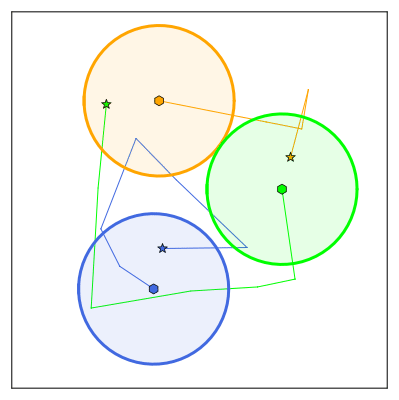

In [4]:
@time plot_anim!(config_init, config_goal, obstacles, ins_params...; solution=res[2], interpolate_depth=3, filename = "./fig/challenging_point2d.gif", fps=30, VERBOSE=1, flg_traj=true)

# point3d

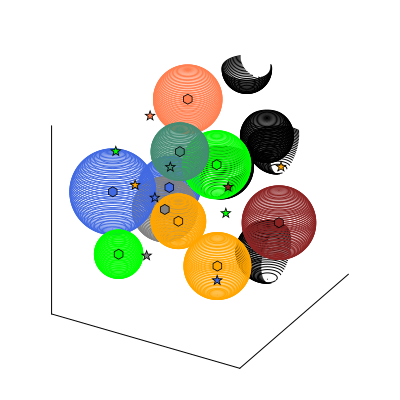

In [5]:
seed!(1)
ins = MRMP.gen_random_instance_StatePoint3D(;
    N = 10,
    rad_min = 0.1,
    rad_max = 0.2,
    num_obs = 5,
    rad_obs_min = 0.1,
    rad_obs_max = 0.15,
)
config_init, config_goal, obstacles, ins_params... = ins
connect = gen_connect(config_init[1], obstacles, ins_params...)
collide = gen_collide(config_init[1], ins_params...)
check_goal = gen_check_goal(config_goal)
planner_args = [config_init, config_goal, connect, collide, check_goal]
MRMP.plot_instance!(ins...)

In [6]:
seed!(0)
@time solution, roadmaps = MRMP.SSSP(planner_args...; 
    TIME_LIMIT = 10,
    VERBOSE = 2,
)
MRMP.validate(config_init, connect, collide, check_goal, solution)
@time res = smoothing(solution, connect, collide)
nothing

		0.2140 sec, explored node: 00000200, f: 0.3626, depth: 0139

[ Info: 	done, setup initial roadmaps


		0.3637 sec, explored node: 00000429, f: 0.0000, depth: 0255  0.949477 seconds (8.17 M allocations: 562.444 MiB, 7.90% gc time, 70.52% compilation time)


┌ Info: 
└ 	0.3637 sec: found solution


  0.454984 seconds (2.48 M allocations: 140.734 MiB, 4.39% gc time, 93.37% compilation time)


plot: 145 / 145 30.564491 seconds (42.79 M allocations: 3.681 GiB, 1.25% gc time, 0.50% compilation time)


Plots.AnimatedGif("/Users/kei18/Dropbox/work/project/sssp/code/notebooks/fig/challenging_point3d.gif")
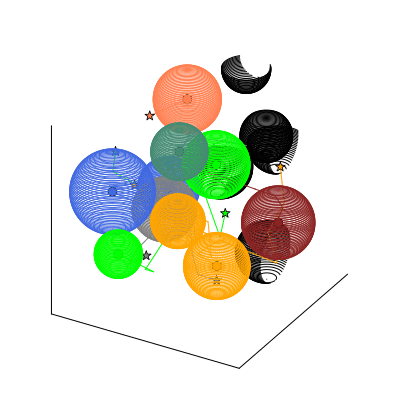

In [7]:
@time plot_anim!(config_init, config_goal, obstacles, ins_params...; solution=res[2], interpolate_depth=3, filename = "./fig/challenging_point3d.gif", fps=30, VERBOSE=1, flg_traj=true)

## line2d

  0.072681 seconds (399.92 k allocations: 21.578 MiB, 12.78% gc time, 67.30% compilation time)


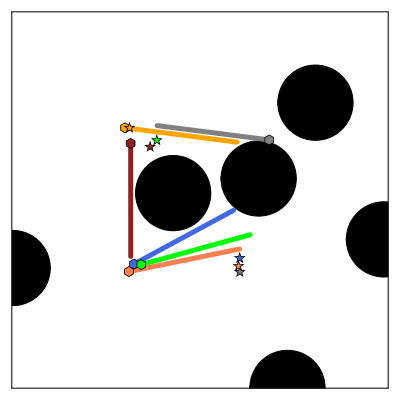

In [8]:
seed!(2)
@time ins = MRMP.gen_random_instance_StateLine2D(;
    N = 6,
    rad = 0.3,
    num_obs = 6,
    rad_obs_min = 0.1,
    rad_obs_max = 0.1,
)
config_init, config_goal, obstacles, ins_params... = ins
connect = gen_connect(config_init[1], obstacles, ins_params...)
collide = gen_collide(config_init[1], ins_params...)
check_goal = gen_check_goal(config_goal)
planner_args = [config_init, config_goal, connect, collide, check_goal]
MRMP.plot_instance!(ins...)

In [9]:
seed!(1)
@time solution, roadmaps = MRMP.SSSP(planner_args...; 
    TIME_LIMIT = 60,
    VERBOSE = 2,
    epsilon = 0.8,
)
MRMP.validate(config_init, connect, collide, check_goal, solution)
@time res = smoothing(solution, connect, collide)
nothing

[ Info: 	done, setup initial roadmaps


		3.2509 sec, explored node: 00000489, f: 0.0000, depth: 0161  3.891339 seconds (63.88 M allocations: 4.718 GiB, 12.73% gc time, 18.65% compilation time)


┌ Info: 
└ 	3.2510 sec: found solution


  1.019752 seconds (13.20 M allocations: 968.667 MiB, 10.09% gc time, 45.10% compilation time)


plot: 161 / 161  5.405418 seconds (9.54 M allocations: 689.442 MiB, 1.53% gc time, 2.62% compilation time)


Plots.AnimatedGif("/Users/kei18/Dropbox/work/project/sssp/code/notebooks/fig/challenging_line2d.gif")
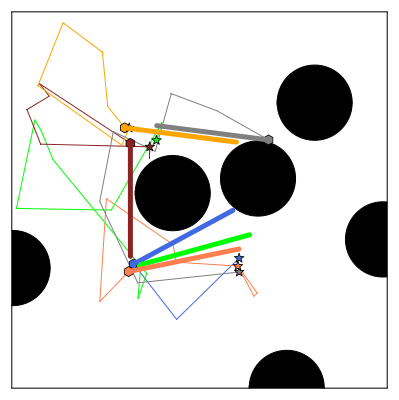

In [10]:
@time plot_anim!(config_init, config_goal, obstacles, ins_params...; solution=res[2], interpolate_depth=3, filename = "./fig/challenging_line2d.gif", fps=30, VERBOSE=1, flg_traj=true)

## capseule3d

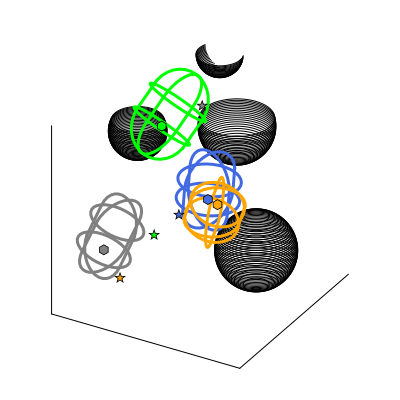

In [11]:
seed!(3)
ins = MRMP.gen_random_instance_StateCapsule3D(;
    N = 4,
    rad_min = 0.1,
    rad_max = 0.2,
    num_obs = 4,
    rad_obs_min = 0.1,
    rad_obs_max = 0.2,
)
config_init, config_goal, obstacles, ins_params... = ins
connect = gen_connect(config_init[1], obstacles, ins_params...)
collide = gen_collide(config_init[1], ins_params...)
check_goal = gen_check_goal(config_goal)
planner_args = [config_init, config_goal, connect, collide, check_goal]
MRMP.plot_instance!(ins...)

In [12]:
seed!(1)
@time solution, roadmaps = MRMP.SSSP(planner_args...; 
    TIME_LIMIT = 60,
    VERBOSE = 2,
)
MRMP.validate(config_init, connect, collide, check_goal, solution)
@time res = smoothing(solution, connect, collide)
nothing

[ Info: 	done, setup initial roadmaps


		54.1313 sec, explored node: 00000315, f: 0.0000, depth: 0157 54.784319 seconds (1.01 G allocations: 65.407 GiB, 9.48% gc time, 1.36% compilation time)


┌ Info: 
└ 	54.1316 sec: found solution


  1.893898 seconds (28.86 M allocations: 1.807 GiB, 7.57% gc time, 25.22% compilation time)


plot: 153 / 153  9.811149 seconds (17.23 M allocations: 1.373 GiB, 1.48% gc time, 1.50% compilation time)


Plots.AnimatedGif("/Users/kei18/Dropbox/work/project/sssp/code/notebooks/fig/challenging_capsule3d.gif")
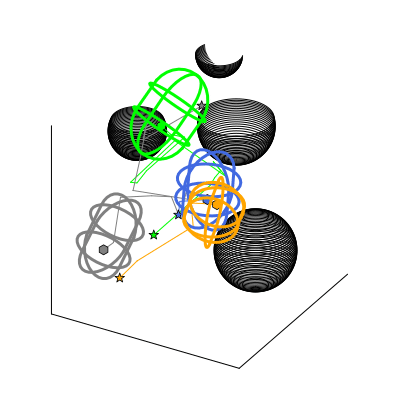

In [13]:
@time plot_anim!(config_init, config_goal, obstacles, ins_params...; solution=res[2], interpolate_depth=3, filename = "./fig/challenging_capsule3d.gif", fps=30, VERBOSE=1, flg_traj=true)

## arm22

  0.083217 seconds (130.94 k allocations: 6.668 MiB, 99.45% compilation time)


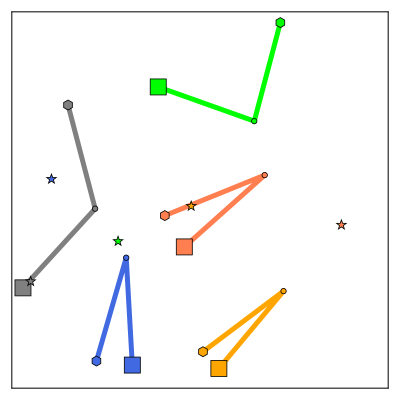

In [14]:
seed!(12)
@time ins = MRMP.gen_random_instance_StateArm22(;
    N = 5,
    rad_min = 0.2,
    rad_max = 0.3,
    num_obs = 0,
    rad_obs_min = 0.2,
    rad_obs_max = 0.2,
)
config_init, config_goal, obstacles, ins_params... = ins
connect = gen_connect(config_init[1], obstacles, ins_params...)
collide = gen_collide(config_init[1], ins_params...)
check_goal = gen_check_goal(config_goal)
planner_args = [config_init, config_goal, connect, collide, check_goal]
MRMP.plot_instance!(ins...)

In [15]:
seed!(2)
@time solution, roadmaps = MRMP.SSSP(
    planner_args...; 
    TIME_LIMIT = 10,
    VERBOSE = 2,
    epsilon = 0.3,
)
@time res = smoothing(solution, connect, collide)
nothing

[ Info: 	done, setup initial roadmaps


		1.1149 sec, explored node: 00000297, f: 0.0000, depth: 0093  1.695417 seconds (24.11 M allocations: 1.714 GiB, 8.33% gc time, 41.78% compilation time)


┌ Info: 
└ 	1.1150 sec: found solution


  1.521131 seconds (25.36 M allocations: 1.823 GiB, 9.17% gc time, 31.45% compilation time)


plot: 97 / 97  2.322533 seconds (3.73 M allocations: 256.518 MiB, 0.96% gc time, 5.59% compilation time)


Plots.AnimatedGif("/Users/kei18/Dropbox/work/project/sssp/code/notebooks/fig/challenging_arm22.gif")
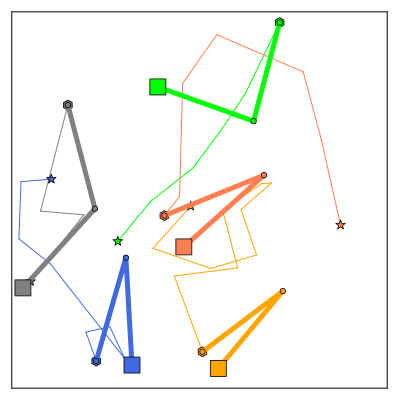

In [16]:
@time plot_anim!(config_init, config_goal, obstacles, ins_params...; solution=res[2], interpolate_depth=3, filename = "./fig/challenging_arm22.gif", fps=30, VERBOSE=1, flg_traj=true)

## arm33

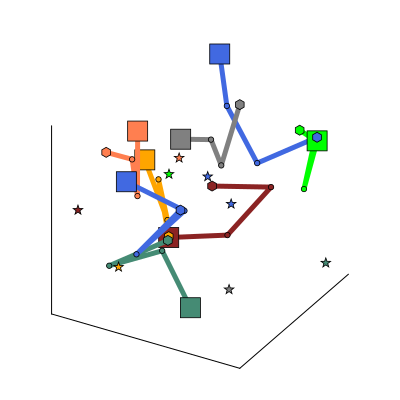

In [17]:
seed!(3)
ins = MRMP.gen_random_instance_StateArm33(;
    N = 8,
    rad = 0.3,
    num_obs = 0,
)
config_init, config_goal, obstacles, ins_params... = ins
connect = gen_connect(config_init[1], obstacles, ins_params...)
collide = gen_collide(config_init[1], ins_params...)
check_goal = gen_check_goal(config_goal)
planner_args = [config_init, config_goal, connect, collide, check_goal]
MRMP.plot_instance!(ins...)

In [18]:
seed!(2)
@time solution, roadmaps = MRMP.SSSP(
    planner_args...; 
    TIME_LIMIT = 10,
    VERBOSE = 2,
)
@time res = smoothing(solution, connect, collide)
nothing

[ Info: 	done, setup initial roadmaps


		4.1177 sec, explored node: 00000097, f: 0.0000, depth: 0095  4.769484 seconds (89.15 M allocations: 6.638 GiB, 10.02% gc time, 15.69% compilation time)


┌ Info: 
└ 	4.1179 sec: found solution


  2.875819 seconds (54.28 M allocations: 4.016 GiB, 9.98% gc time, 18.15% compilation time)


plot: 105 / 105  3.356227 seconds (6.46 M allocations: 446.078 MiB, 1.24% gc time, 4.07% compilation time)


Plots.AnimatedGif("/Users/kei18/Dropbox/work/project/sssp/code/notebooks/fig/challenging_arm33.gif")
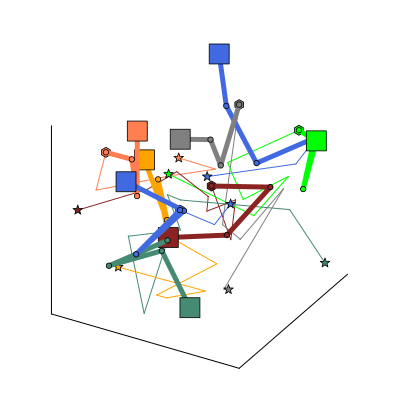

In [19]:
@time plot_anim!(config_init, config_goal, obstacles, ins_params...; solution=res[2], interpolate_depth=3, filename = "./fig/challenging_arm33.gif", fps=30, VERBOSE=1, flg_traj=true)

## dubins2d

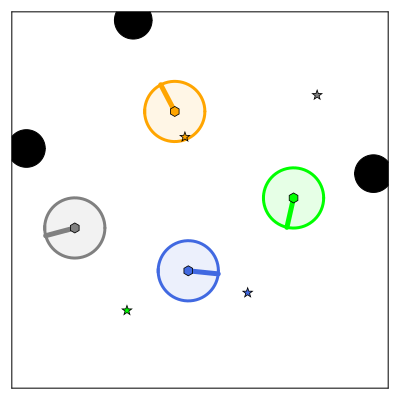

In [20]:
seed!(9)
ins = MRMP.gen_random_instance_StateDubins(;
    N = 4,
    rad = 0.08,
    num_obs = 3,
    rad_obs = 0.05,
)
config_init, config_goal, obstacles, ins_params... = ins
connect = gen_connect(config_init[1], obstacles, ins_params...)
collide = gen_collide(config_init[1], ins_params...)
check_goal = gen_check_goal(config_goal)
planner_args = [config_init, config_goal, connect, collide, check_goal]
MRMP.plot_instance!(ins...)

In [21]:
seed!(3)
@time solution, roadmaps = MRMP.SSSP(
    planner_args...; 
    TIME_LIMIT = 30,
    VERBOSE = 2,
)
@time res = smoothing(solution, connect, collide)
nothing

[ Info: 	done, setup initial roadmaps


		3.3703 sec, explored node: 00001476, f: 0.0000, depth: 0073  4.177035 seconds (51.20 M allocations: 3.289 GiB, 6.70% gc time, 22.27% compilation time)


┌ Info: 
└ 	3.3704 sec: found solution


  0.549474 seconds (2.32 M allocations: 122.697 MiB, 2.37% gc time, 96.48% compilation time)


plot: 241 / 241  4.946569 seconds (6.48 M allocations: 469.080 MiB, 1.27% gc time, 3.61% compilation time)


Plots.AnimatedGif("/Users/kei18/Dropbox/work/project/sssp/code/notebooks/fig/challenging_dubins2d.gif")
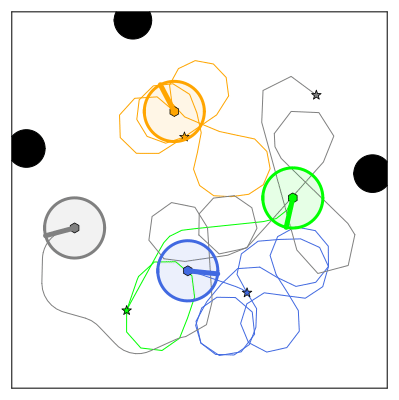

In [22]:
@time plot_anim!(config_init, config_goal, obstacles, ins_params...; solution=res[2], interpolate_depth=4, filename = "./fig/challenging_dubins2d.gif", fps=30, VERBOSE=1, flg_traj=true)

## snake2d

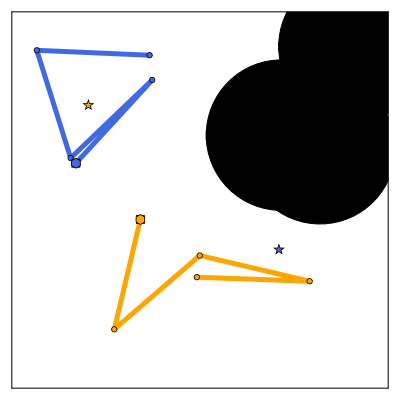

In [23]:
seed!(14)
ins = MRMP.gen_random_instance_StateSnake2D(;
    N = 2,
    rad = 0.3,
    num_obs = 3,
    rad_obs = 0.2
)
config_init, config_goal, obstacles, ins_params... = ins
connect = gen_connect(config_init[1], obstacles, ins_params...)
collide = gen_collide(config_init[1], ins_params...)
check_goal = gen_check_goal(config_goal)
planner_args = [config_init, config_goal, connect, collide, check_goal]
MRMP.plot_instance!(ins...)

In [24]:
seed!(0)
@time solution, roadmaps = MRMP.SSSP(
    planner_args...; 
    TIME_LIMIT = 30,
    VERBOSE = 2,
)
@time res = smoothing(solution, connect, collide)
nothing

[ Info: 	done, setup initial roadmaps


		19.3489 sec, explored node: 00000249, f: 0.0000, depth: 0062 20.020288 seconds (441.70 M allocations: 32.788 GiB, 11.30% gc time, 3.83% compilation time)


┌ Info: 
└ 	19.3491 sec: found solution


  3.439023 seconds (69.74 M allocations: 5.176 GiB, 10.37% gc time, 15.69% compilation time)


plot: 353 / 353  6.673825 seconds (8.74 M allocations: 632.172 MiB, 0.85% gc time, 1.94% compilation time)


Plots.AnimatedGif("/Users/kei18/Dropbox/work/project/sssp/code/notebooks/fig/challenging_snake2d.gif")
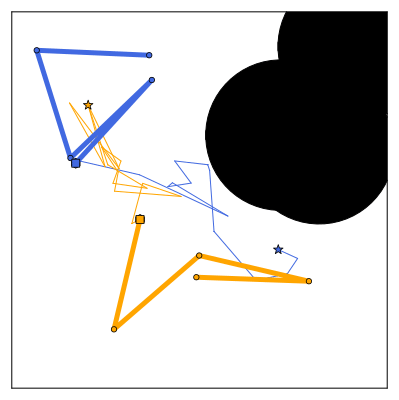

In [25]:
@time plot_anim!(config_init, config_goal, obstacles, ins_params...; solution=res[2], interpolate_depth=4, filename = "./fig/challenging_snake2d.gif", fps=30, VERBOSE=1, flg_traj=true)

## point2d many

  0.000249 seconds (7.12 k allocations: 516.062 KiB)


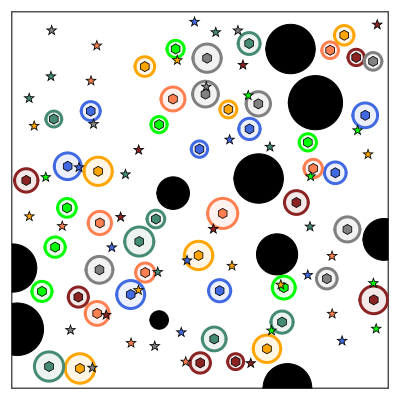

In [26]:
seed!(2)
@time ins = MRMP.gen_random_instance_StatePoint2D(;
    N = 50,
    rad_min = 0.02,
    rad_max = 0.04,
    num_obs = 10,
    rad_obs_min = 0.02,
    rad_obs_max = 0.08,
    TIME_LIMIT = 10
)
config_init, config_goal, obstacles, ins_params... = ins
connect = gen_connect(config_init[1], obstacles, ins_params...)
collide = gen_collide(config_init[1], ins_params...)
check_goal = gen_check_goal(config_goal)
planner_args = [config_init, config_goal, connect, collide, check_goal]
MRMP.plot_instance!(ins...)

In [27]:
seed!(1)
@time solution, roadmaps = MRMP.Solvers.SSSP(
    config_init,
    config_goal,
    connect,
    collide,
    check_goal;
    VERBOSE = 1,
    TIME_LIMIT = 300,
    steering_depth = 2,
    num_vertex_expansion = 10,
    init_min_dist_thread = 0.05,
    epsilon = 0.2,
)
MRMP.validate(config_init, connect, collide, check_goal, solution)

@time res = smoothing(solution, connect, collide)
nothing

		0.1731 sec, explored node: 00000200, f: 0.4591, depth: 0188

[ Info: 	done, setup initial roadmaps


		194.7007 sec, explored node: 00313292, f: 0.0000, depth: 15127194.923997 seconds (3.60 G allocations: 276.141 GiB, 21.59% gc time, 0.14% compilation time)


┌ Info: 
└ 	194.7009 sec: found solution


 16.834782 seconds (477.36 M allocations: 31.738 GiB, 12.36% gc time)


plot: 429 / 429 20.641331 seconds (33.48 M allocations: 2.569 GiB, 1.28% gc time, 0.03% compilation time)


Plots.AnimatedGif("/Users/kei18/Dropbox/work/project/sssp/code/notebooks/fig/challenging_point2d_many.gif")
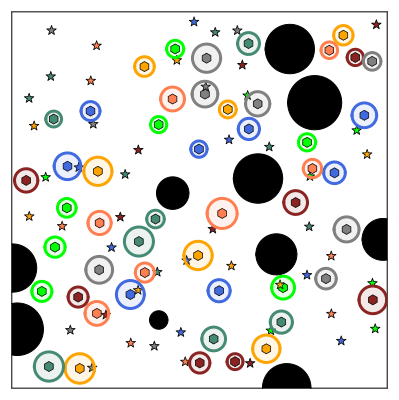

In [28]:
@time plot_anim!(config_init, config_goal, obstacles, ins_params...; solution=res[2], interpolate_depth=2, filename = "./fig/challenging_point2d_many.gif", fps=30, VERBOSE=1)